# CAFA-6 Graph Evaluation Results Analysis

In [1]:
# =============================
# 0. Setup and load evaluator result folders
# =============================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RESULT_SETS = {
    "ensemble_original": Path("../cafa6_graph_results"),
    "submodels": Path("../cafa6_graph_submodels_results"),
}

missing = [name for name, path in RESULT_SETS.items() if not (path / "evaluation_all.tsv").exists()]
if missing:
    raise FileNotFoundError(f"Missing result sets: {missing}")

print("[RESULT SETS]")
for name, path in RESULT_SETS.items():
    print(f"\n{name}: {path.resolve()}")
    for p in sorted(path.glob("*.tsv")):
        print(f"  - {p.name} ({p.stat().st_size / 1024:.1f} KB)")


def dedupe_columns(columns):
    seen = {}
    out = []
    for col in [str(c).strip() for c in columns]:
        if col not in seen:
            seen[col] = 0
            out.append(col)
        else:
            seen[col] += 1
            out.append(f"{col}__dup{seen[col]}")
    return out


def read_tsv(path):
    df = pd.read_csv(path, sep="\t")
    df.columns = dedupe_columns(df.columns)
    return df

all_tables = []
best_tables = []
for result_name, result_dir in RESULT_SETS.items():
    df = read_tsv(result_dir / "evaluation_all.tsv")
    df["_result_set"] = result_name
    all_tables.append(df)
    for p in sorted(result_dir.glob("evaluation_best_*.tsv")):
        metric = p.stem.replace("evaluation_best_", "")
        b = read_tsv(p)
        b["_result_set"] = result_name
        b["_best_metric_file"] = metric
        best_tables.append(b)

eval_all_raw = pd.concat(all_tables, ignore_index=True)
best_raw = pd.concat(best_tables, ignore_index=True)

print(f"[LOAD] eval_all_raw={eval_all_raw.shape}")
print(f"[LOAD] best_raw={best_raw.shape}")
display(eval_all_raw.head())
display(best_raw.head())

[RESULT SETS]

ensemble_original: /Users/duongminhquan/Documents/BioInformatics/cafa6_graph_results
  - evaluation_all.tsv (47.6 KB)
  - evaluation_best_f.tsv (0.8 KB)
  - evaluation_best_f_micro.tsv (0.8 KB)
  - evaluation_best_f_micro_w.tsv (0.8 KB)
  - evaluation_best_f_w.tsv (0.8 KB)
  - evaluation_best_s.tsv (0.8 KB)

submodels: /Users/duongminhquan/Documents/BioInformatics/cafa6_graph_submodels_results
  - evaluation_all.tsv (193.1 KB)
  - evaluation_best_f.tsv (2.7 KB)
  - evaluation_best_f_micro.tsv (2.7 KB)
  - evaluation_best_f_micro_w.tsv (2.8 KB)
  - evaluation_best_f_w.tsv (2.7 KB)
  - evaluation_best_s.tsv (2.7 KB)
[LOAD] eval_all_raw=(1138, 32)
[LOAD] best_raw=(75, 34)


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,_result_set
0,graph_aware.tsv,biological_process,0.01,7367.0,9.132,997.549,0.294,0.009,0.974,1.0,997.549,0.294,0.018,997.549,0.009,0.969,0.018,7299.0,9.546,1158.551,0.304,0.008,0.978,1.0,1158.551,0.304,0.016,1158.551,0.008,0.969,0.016,ensemble_original
1,graph_aware.tsv,biological_process,0.02,7367.0,9.129,982.559,0.297,0.009,0.973,1.0,982.559,0.297,0.018,982.559,0.009,0.969,0.018,7299.0,9.543,1141.636,0.307,0.008,0.978,1.0,1141.636,0.307,0.016,1141.636,0.008,0.969,0.016,ensemble_original
2,graph_aware.tsv,biological_process,0.03,7367.0,9.096,907.390,0.330,0.010,0.968,1.0,907.390,0.330,0.019,907.390,0.010,0.965,0.020,7299.0,9.506,1054.644,0.344,0.009,0.974,1.0,1054.644,0.344,0.018,1054.644,0.009,0.965,0.018,ensemble_original
3,graph_aware.tsv,biological_process,0.04,7367.0,9.001,779.655,0.425,0.011,0.955,1.0,779.655,0.425,0.023,779.655,0.011,0.955,0.023,7299.0,9.396,904.164,0.455,0.010,0.962,1.0,904.164,0.455,0.021,904.165,0.010,0.954,0.020,ensemble_original
4,graph_aware.tsv,biological_process,0.05,7367.0,8.844,637.947,0.582,0.014,0.936,1.0,637.947,0.582,0.028,637.947,0.014,0.938,0.027,7299.0,9.216,737.744,0.634,0.013,0.944,1.0,737.744,0.634,0.025,737.744,0.012,0.936,0.024,ensemble_original


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file
0,graph_aware.tsv,biological_process,0.35,6753.0,2.418,8.510,7.008,0.252,0.281,0.917,8.510,7.008,0.266,11.024,0.221,0.257,0.238,6681.0,2.363,9.429,7.487,0.249,0.290,0.915,9.429,7.487,0.268,12.041,0.200,0.240,0.218,1.0,ensemble_original,f
1,graph_aware.tsv,cellular_component,0.41,8724.0,2.948,2.789,3.158,0.578,0.594,0.991,2.789,3.158,0.586,4.214,0.514,0.483,0.498,8724.0,3.113,3.930,4.642,0.542,0.535,0.991,3.930,4.642,0.539,6.082,0.442,0.401,0.421,1.0,ensemble_original,f
2,graph_aware.tsv,molecular_function,0.39,7159.0,1.938,2.271,2.073,0.558,0.590,0.968,2.271,2.073,0.573,3.075,0.460,0.483,0.471,7159.0,1.871,3.342,4.152,0.503,0.539,0.968,3.342,4.152,0.520,5.330,0.359,0.311,0.333,1.0,ensemble_original,f
3,graph_aware.tsv,biological_process,0.36,6597.0,2.273,7.430,7.153,0.264,0.265,0.895,7.430,7.153,0.264,10.314,0.234,0.241,0.238,6526.0,2.208,8.213,7.642,0.262,0.274,0.894,8.213,7.642,0.268,11.219,0.212,0.224,0.218,1.0,ensemble_original,f_micro
4,graph_aware.tsv,cellular_component,0.40,8749.0,3.065,3.135,3.041,0.559,0.612,0.994,3.135,3.041,0.584,4.367,0.494,0.502,0.498,8749.0,3.274,4.442,4.480,0.521,0.555,0.994,4.442,4.480,0.538,6.309,0.424,0.422,0.423,1.0,ensemble_original,f_micro


In [2]:
# =============================
# 1. Normalize columns
# =============================
def find_col(df, candidates, contains=None):
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    if contains:
        for col in df.columns:
            lc = col.lower()
            if all(token.lower() in lc for token in contains):
                return col
    return None

method_col = find_col(eval_all_raw, ["filename", "file", "method", "model", "pred_file"], contains=["file"])
namespace_col = find_col(eval_all_raw, ["namespace", "ontology", "aspect", "ns"], contains=["namespace"])
threshold_col = find_col(eval_all_raw, ["threshold", "th", "tau", "cutoff"], contains=["th"])

f_col = find_col(eval_all_raw, ["f", "fmax", "f_max", "F", "Fmax"])
fw_col = find_col(eval_all_raw, ["f_w", "wf", "wF", "weighted_f", "weighted_fmax", "f_weighted"], contains=["f", "w"])
f_micro_col = find_col(eval_all_raw, ["f_micro", "micro_f", "micro_f1"], contains=["f", "micro"])
f_micro_w_col = find_col(eval_all_raw, ["f_micro_w", "micro_f_w", "weighted_micro_f"], contains=["f", "micro", "w"])
precision_col = find_col(eval_all_raw, ["precision", "pr", "p"], contains=["precision"])
recall_col = find_col(eval_all_raw, ["recall", "rc", "r"], contains=["recall"])
s_col = find_col(eval_all_raw, ["s", "smin", "s_min", "S", "Smin"])

def first_existing_unique(cols):
    seen = set()
    for col in cols:
        if col is None or col in seen:
            continue
        seen.add(col)
        if col in eval_all_raw.columns:
            return col
    return None

# Prefer exact non-duplicate evaluator columns over duplicate-renamed variants.
f_col = first_existing_unique([f_col])
fw_col = first_existing_unique([fw_col])
f_micro_col = first_existing_unique([f_micro_col])
f_micro_w_col = first_existing_unique([f_micro_w_col])
precision_col = first_existing_unique([precision_col])
recall_col = first_existing_unique([recall_col])
s_col = first_existing_unique([s_col])

print("[DETECTED COLUMNS]")
for name, col in {
    "method": method_col,
    "namespace": namespace_col,
    "threshold": threshold_col,
    "f": f_col,
    "f_w": fw_col,
    "f_micro": f_micro_col,
    "f_micro_w": f_micro_w_col,
    "precision": precision_col,
    "recall": recall_col,
    "s": s_col,
}.items():
    print(f"  {name:14s}: {col}")

eval_all = eval_all_raw.copy()
eval_all["_method"] = eval_all[method_col].astype(str).str.replace(".tsv", "", regex=False) if method_col else "method"
eval_all["_namespace"] = eval_all[namespace_col].astype(str) if namespace_col else "all"
eval_all["_threshold"] = pd.to_numeric(eval_all[threshold_col], errors="coerce") if threshold_col else np.nan

for col in [f_col, fw_col, f_micro_col, f_micro_w_col, precision_col, recall_col, s_col]:
    if col is not None and col in eval_all.columns:
        eval_all[col] = pd.to_numeric(eval_all[col], errors="coerce")

best = best_raw.copy()
if method_col and method_col in best.columns:
    best["_method"] = best[method_col].astype(str).str.replace(".tsv", "", regex=False)
else:
    b_method_col = find_col(best, ["filename", "file", "method", "model", "pred_file"], contains=["file"])
    best["_method"] = best[b_method_col].astype(str).str.replace(".tsv", "", regex=False) if b_method_col else "method"
if namespace_col and namespace_col in best.columns:
    best["_namespace"] = best[namespace_col].astype(str)
else:
    b_ns_col = find_col(best, ["namespace", "ontology", "aspect", "ns"], contains=["namespace"])
    best["_namespace"] = best[b_ns_col].astype(str) if b_ns_col else "all"

print("\nMethods by result set:")
for rs, g in eval_all.groupby("_result_set"):
    print(rs, sorted(g["_method"].unique().tolist()))
print("Namespaces:", sorted(eval_all["_namespace"].unique().tolist()))

[DETECTED COLUMNS]
  method        : filename
  namespace     : ns
  threshold     : tau
  f             : f
  f_w           : f_w
  f_micro       : f_micro
  f_micro_w     : f_micro_w
  precision     : pr
  recall        : rc
  s             : s

Methods by result set:
ensemble_original ['graph_aware']
submodels ['bilstm_attention', 'ensemble', 'esm_mlp', 'protcnn']
Namespaces: ['biological_process', 'cellular_component', 'molecular_function']


In [3]:
# =============================
# 2. Show evaluator best files
# =============================
for (rs, metric), df in best.groupby(["_result_set", "_best_metric_file"]):
    print(f"\n=== {rs} | evaluation_best_{metric}.tsv | shape={df.shape} ===")
    display(df)


=== ensemble_original | evaluation_best_f.tsv | shape=(3, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
0,graph_aware.tsv,biological_process,0.35,6753.0,2.418,8.510,7.008,0.252,0.281,0.917,8.510,7.008,0.266,11.024,0.221,0.257,0.238,6681.0,2.363,9.429,7.487,0.249,0.290,0.915,9.429,7.487,0.268,12.041,0.200,0.240,0.218,1.0,ensemble_original,f,graph_aware,biological_process
1,graph_aware.tsv,cellular_component,0.41,8724.0,2.948,2.789,3.158,0.578,0.594,0.991,2.789,3.158,0.586,4.214,0.514,0.483,0.498,8724.0,3.113,3.930,4.642,0.542,0.535,0.991,3.930,4.642,0.539,6.082,0.442,0.401,0.421,1.0,ensemble_original,f,graph_aware,cellular_component
2,graph_aware.tsv,molecular_function,0.39,7159.0,1.938,2.271,2.073,0.558,0.590,0.968,2.271,2.073,0.573,3.075,0.460,0.483,0.471,7159.0,1.871,3.342,4.152,0.503,0.539,0.968,3.342,4.152,0.520,5.330,0.359,0.311,0.333,1.0,ensemble_original,f,graph_aware,molecular_function



=== ensemble_original | evaluation_best_f_micro.tsv | shape=(3, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
3,graph_aware.tsv,biological_process,0.36,6597.0,2.273,7.430,7.153,0.264,0.265,0.895,7.430,7.153,0.264,10.314,0.234,0.241,0.238,6526.0,2.208,8.213,7.642,0.262,0.274,0.894,8.213,7.642,0.268,11.219,0.212,0.224,0.218,1.0,ensemble_original,f_micro,graph_aware,biological_process
4,graph_aware.tsv,cellular_component,0.40,8749.0,3.065,3.135,3.041,0.559,0.612,0.994,3.135,3.041,0.584,4.367,0.494,0.502,0.498,8749.0,3.274,4.442,4.480,0.521,0.555,0.994,4.442,4.480,0.538,6.309,0.424,0.422,0.423,1.0,ensemble_original,f_micro,graph_aware,cellular_component
5,graph_aware.tsv,molecular_function,0.41,7026.0,1.812,1.862,2.198,0.590,0.555,0.950,1.862,2.198,0.572,2.880,0.493,0.452,0.472,7026.0,1.679,2.588,4.344,0.544,0.504,0.950,2.588,4.344,0.523,5.056,0.393,0.279,0.326,1.0,ensemble_original,f_micro,graph_aware,molecular_function



=== ensemble_original | evaluation_best_f_micro_w.tsv | shape=(3, 36) ===


...

,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
39,bilstm_attention.tsv,biological_process,0.20,7367.0,1.647,12.080,7.778,0.124,0.183,1.000,12.080,7.778,0.147,14.368,0.120,0.175,0.142,7299.0,1.249,8.509,8.601,0.138,0.173,1.000,8.509,8.601,0.153,12.099,0.128,0.127,0.127,1.0,submodels,f_micro_w,bilstm_attention,biological_process
40,bilstm_attention.tsv,cellular_component,0.24,8800.0,2.734,6.261,3.372,0.305,0.583,1.000,6.261,3.372,0.401,7.112,0.304,0.448,0.362,8800.0,2.661,9.821,5.094,0.213,0.527,1.000,9.821,5.094,0.304,11.063,0.213,0.343,0.263,1.0,submodels,f_micro_w,bilstm_attention,cellular_component
41,bilstm_attention.tsv,molecular_function,0.20,7397.0,1.558,6.304,2.453,0.221,0.556,1.000,6.304,2.453,0.316,6.765,0.198,0.388,0.262,7397.0,1.387,9.349,4.635,0.141,0.513,1.000,9.349,4.635,0.221,10.435,0.129,0.230,0.166,1.0,submodels,f_micro_w,bilstm_attention,molecular_function
42,ensemble.tsv,biological_process,0.35,6753.0,2.418,8.510,7.008,0.252,0.281,0.917,8.510,7.008,0.266,11.024,0.221,0.257,0.238,6681.0,2.363,9.429,7.487,0.249,0.290,0.915,9.429,7.487,0.268,12.041,0.200,0.240,0.218,1.0,submodels,f_micro_w,ensemble,biological_process
43,ensemble.tsv,cellular_component,0.39,8760.0,3.176,3.489,2.930,0.543,0.630,0.995,3.489,2.930,0.583,4.556,0.476,0.520,0.497,8760.0,3.422,4.966,4.332,0.503,0.575,0.995,4.966,4.332,0.537,6.590,0.408,0.441,0.424,1.0,submodels,f_micro_w,ensemble,cellular_component
44,ensemble.tsv,molecular_function,0.37,7245.0,2.069,2.758,1.942,0.524,0.622,0.979,2.758,1.942,0.569,3.373,0.429,0.516,0.468,7245.0,2.079,4.244,3.944,0.462,0.572,0.979,4.244,3.944,0.511,5.794,0.329,0.345,0.337,1.0,submodels,f_micro_w,ensemble,molecular_function
45,esm_mlp.tsv,biological_process,0.56,5692.0,2.052,7.277,7.374,0.263,0.248,0.773,7.277,7.374,0.255,10.360,0.220,0.218,0.219,5612.0,2.019,8.400,7.832,0.255,0.256,0.769,8.400,7.832,0.255,11.485,0.194,0.205,0.199,1.0,submodels,f_micro_w,esm_mlp,biological_process
46,esm_mlp.tsv,cellular_component,0.57,7969.0,2.701,3.396,3.405,0.553,0.519,0.906,3.396,3.405,0.535,4.809,0.443,0.442,0.443,7969.0,3.083,5.214,4.672,0.516,0.482,0.906,5.214,4.672,0.499,7.001,0.372,0.398,0.384,1.0,submodels,f_micro_w,esm_mlp,cellular_component
47,esm_mlp.tsv,molecular_function,0.61,6015.0,1.677,2.167,2.333,0.529,0.444,0.813,2.167,2.333,0.483,3.184,0.436,0.418,0.427,6015.0,1.803,3.340,4.220,0.497,0.415,0.813,3.340,4.220,0.452,5.382,0.351,0.299,0.323,1.0,submodels,f_micro_w,esm_mlp,molecular_function
48,protcnn.tsv,biological_process,0.31,7171.0,1.749,12.029,7.677,0.152,0.192,0.973,12.029,7.677,0.170,14.270,0.127,0.186,0.151,7104.0,1.561,12.477,8.289,0.153,0.195,0.973,12.477,8.289,0.172,14.979,0.111,0.159,0.131,1.0,submodels,f_micro_w,protcnn,biological_process



=== submodels | evaluation_best_f_w.tsv | shape=(12, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
51,bilstm_attention.tsv,biological_process,0.21,7367.0,1.492,9.916,7.933,0.135,0.167,1.000,9.916,7.933,0.149,12.699,0.131,0.158,0.143,7299.0,1.123,6.750,8.727,0.150,0.159,1.000,6.750,8.727,0.154,11.033,0.143,0.114,0.127,1.0,submodels,f_w,bilstm_attention,biological_process
52,bilstm_attention.tsv,cellular_component,0.29,8800.0,2.173,3.551,3.933,0.385,0.474,1.000,3.551,3.933,0.425,5.299,0.380,0.356,0.367,8800.0,1.655,4.558,6.100,0.276,0.361,1.000,4.558,6.100,0.313,7.615,0.266,0.213,0.237,1.0,submodels,f_w,bilstm_attention,cellular_component
53,bilstm_attention.tsv,molecular_function,0.37,7128.0,0.676,0.610,3.334,0.546,0.320,0.964,0.610,3.334,0.404,3.389,0.526,0.169,0.255,7128.0,0.349,0.825,5.674,0.495,0.277,0.964,0.825,5.674,0.355,5.734,0.297,0.058,0.097,1.0,submodels,f_w,bilstm_attention,molecular_function
54,ensemble.tsv,biological_process,0.35,6753.0,2.418,8.510,7.008,0.252,0.281,0.917,8.510,7.008,0.266,11.024,0.221,0.257,0.238,6681.0,2.363,9.429,7.487,0.249,0.290,0.915,9.429,7.487,0.268,12.041,0.200,0.240,0.218,1.0,submodels,f_w,ensemble,biological_process
55,ensemble.tsv,cellular_component,0.41,8724.0,2.948,2.789,3.158,0.578,0.594,0.991,2.789,3.158,0.586,4.214,0.514,0.483,0.498,8724.0,3.113,3.930,4.642,0.542,0.535,0.991,3.930,4.642,0.539,6.082,0.442,0.401,0.421,1.0,submodels,f_w,ensemble,cellular_component
56,ensemble.tsv,molecular_function,0.41,7026.0,1.812,1.862,2.198,0.590,0.555,0.950,1.862,2.198,0.572,2.880,0.493,0.452,0.472,7026.0,1.679,2.588,4.344,0.544,0.504,0.950,2.588,4.344,0.523,5.056,0.393,0.279,0.326,1.0,submodels,f_w,ensemble,molecular_function
57,esm_mlp.tsv,biological_process,0.53,6055.0,2.282,9.148,7.144,0.244,0.272,0.822,9.148,7.144,0.257,11.607,0.200,0.242,0.219,5976.0,2.255,10.589,7.595,0.236,0.280,0.819,10.589,7.595,0.256,13.031,0.176,0.229,0.199,1.0,submodels,f_w,esm_mlp,biological_process
58,esm_mlp.tsv,cellular_component,0.53,8319.0,2.992,4.383,3.114,0.518,0.570,0.945,4.383,3.114,0.543,5.377,0.406,0.490,0.444,8319.0,3.415,6.722,4.339,0.477,0.529,0.945,6.722,4.339,0.502,8.001,0.337,0.440,0.382,1.0,submodels,f_w,esm_mlp,cellular_component
59,esm_mlp.tsv,molecular_function,0.53,6780.0,2.024,3.397,1.987,0.478,0.551,0.917,3.397,1.987,0.512,3.935,0.373,0.505,0.429,6780.0,2.222,5.703,3.801,0.430,0.513,0.917,5.703,3.801,0.468,6.854,0.280,0.369,0.319,1.0,submodels,f_w,esm_mlp,molecular_function
60,protcnn.tsv,biological_process,0.30,7299.0,1.904,14.197,7.522,0.143,0.209,0.991,14.197,7.522,0.170,16.067,0.118,0.202,0.149,7230.0,1.714,14.879,8.136,0.146,0.212,0.991,14.879,8.136,0.173,16.958,0.103,0.174,0.130,1.0,submodels,f_w,protcnn,biological_process



=== submodels | evaluation_best_s.tsv | shape=(12, 36) ===


,filename,ns,tau,n,tp,fp,fn,pr,rc,cov,mi,ru,f,s,pr_micro,rc_micro,f_micro,n_w,tp_w,fp_w,fn_w,pr_w,rc_w,cov_w,mi_w,ru_w,f_w,s_w,pr_micro_w,rc_micro_w,f_micro_w,cov_max,_result_set,_best_metric_file,_method,_namespace
63,bilstm_attention.tsv,biological_process,0.30,4140.0,0.557,1.875,8.869,0.232,0.063,0.562,1.875,8.869,0.099,9.065,0.229,0.059,0.094,4120.0,0.397,1.098,9.453,0.265,0.061,0.564,1.098,9.453,0.099,9.517,0.266,0.040,0.070,1.0,submodels,s,bilstm_attention,biological_process
64,bilstm_attention.tsv,cellular_component,0.36,8800.0,1.666,1.639,4.440,0.513,0.366,1.000,1.639,4.440,0.427,4.733,0.504,0.273,0.354,8800.0,0.893,1.342,6.861,0.442,0.229,1.000,1.342,6.861,0.302,6.991,0.400,0.115,0.179,1.0,submodels,s,bilstm_attention,cellular_component
65,bilstm_attention.tsv,molecular_function,0.32,7397.0,0.900,1.166,3.111,0.444,0.399,1.000,1.166,3.111,0.421,3.322,0.436,0.224,0.296,7397.0,0.550,1.531,5.473,0.323,0.353,1.000,1.531,5.473,0.338,5.683,0.264,0.091,0.136,1.0,submodels,s,bilstm_attention,molecular_function
66,ensemble.tsv,biological_process,0.44,4674.0,1.261,2.269,8.165,0.378,0.153,0.634,2.269,8.165,0.218,8.474,0.357,0.134,0.195,4605.0,1.156,2.318,8.694,0.376,0.159,0.631,2.318,8.694,0.223,8.997,0.333,0.117,0.174,1.0,submodels,s,ensemble,biological_process
67,ensemble.tsv,cellular_component,0.45,8558.0,2.485,1.694,3.621,0.647,0.514,0.973,1.694,3.621,0.573,3.997,0.595,0.407,0.483,8558.0,2.510,2.300,5.245,0.621,0.450,0.973,2.300,5.245,0.522,5.727,0.522,0.324,0.399,1.0,submodels,s,ensemble,cellular_component
68,ensemble.tsv,molecular_function,0.46,6553.0,1.507,1.150,2.503,0.653,0.473,0.886,1.150,2.503,0.549,2.754,0.567,0.376,0.452,6553.0,1.260,1.380,4.763,0.627,0.422,0.886,1.380,4.763,0.504,4.959,0.477,0.209,0.291,1.0,submodels,s,ensemble,molecular_function
69,esm_mlp.tsv,biological_process,0.69,3850.0,1.194,2.409,8.232,0.370,0.150,0.523,2.409,8.232,0.214,8.577,0.331,0.127,0.183,3792.0,1.150,2.721,8.701,0.366,0.156,0.520,2.721,8.701,0.219,9.116,0.297,0.117,0.168,1.0,submodels,s,esm_mlp,biological_process
70,esm_mlp.tsv,cellular_component,0.64,7004.0,2.153,2.100,3.953,0.606,0.418,0.796,2.100,3.953,0.495,4.476,0.506,0.353,0.416,7004.0,2.470,3.218,5.284,0.580,0.390,0.796,3.218,5.284,0.467,6.187,0.434,0.319,0.368,1.0,submodels,s,esm_mlp,cellular_component
71,esm_mlp.tsv,molecular_function,0.69,4874.0,1.307,1.348,2.703,0.561,0.321,0.659,1.348,2.703,0.408,3.020,0.492,0.326,0.392,4874.0,1.387,1.876,4.636,0.543,0.300,0.659,1.876,4.636,0.387,5.001,0.425,0.230,0.299,1.0,submodels,s,esm_mlp,molecular_function
72,protcnn.tsv,biological_process,0.41,3865.0,0.575,1.804,8.851,0.258,0.065,0.525,1.804,8.851,0.104,9.033,0.242,0.061,0.097,3788.0,0.476,1.737,9.374,0.259,0.064,0.519,1.737,9.374,0.103,9.534,0.215,0.048,0.079,1.0,submodels,s,protcnn,biological_process


In [4]:
# =============================
# 3. Best score summary recomputed from evaluation_all
# =============================
def best_by_metric(df, metric_col, higher_is_better=True):
    if metric_col is None or metric_col not in df.columns:
        return pd.DataFrame()
    rows = []
    for (rs, method, ns), g in df.dropna(subset=[metric_col]).groupby(["_result_set", "_method", "_namespace"]):
        idx = g[metric_col].idxmax() if higher_is_better else g[metric_col].idxmin()
        rows.append(g.loc[idx].to_dict())
    out = pd.DataFrame(rows)
    out["selected_metric"] = metric_col
    return out

summary_parts = []
for metric_col, higher in [(f_col, True), (fw_col, True), (f_micro_col, True), (f_micro_w_col, True), (s_col, False)]:
    tmp = best_by_metric(eval_all, metric_col, higher)
    if len(tmp):
        summary_parts.append(tmp)

best_summary = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
cols = [c for c in ["selected_metric", "_result_set", "_method", "_namespace", "_threshold", f_col, fw_col, f_micro_col, f_micro_w_col, s_col, precision_col, recall_col] if c and c in best_summary.columns]
display(best_summary[cols].sort_values(["selected_metric", "_result_set", "_method", "_namespace"]))

,selected_metric,_result_set,_method,_namespace,_threshold,f,f_w,f_micro,f_micro_w,s,pr,rc
0,f,ensemble_original,graph_aware,biological_process,0.35,0.266,0.268,0.238,0.218,11.024,0.252,0.281
1,f,ensemble_original,graph_aware,cellular_component,0.41,0.586,0.539,0.498,0.421,4.214,0.578,0.594
2,f,ensemble_original,graph_aware,molecular_function,0.39,0.573,0.520,0.471,0.333,3.075,0.558,0.590
3,f,submodels,bilstm_attention,biological_process,0.21,0.149,0.154,0.143,0.127,12.699,0.135,0.167
4,f,submodels,bilstm_attention,cellular_component,0.34,0.431,0.313,0.360,0.199,4.759,0.483,0.389
...,...,...,...,...,...,...,...,...,...,...,...,...
70,s,submodels,esm_mlp,cellular_component,0.64,0.495,0.467,0.416,0.368,4.476,0.606,0.418
71,s,submodels,esm_mlp,molecular_function,0.69,0.408,0.387,0.392,0.299,3.020,0.561,0.321
72,s,submodels,protcnn,biological_process,0.41,0.104,0.103,0.097,0.079,9.033,0.258,0.065
73,s,submodels,protcnn,cellular_component,0.45,0.473,0.377,0.376,0.245,4.637,0.562,0.409


Preferred metric: f_w


,_method,_namespace,_threshold,f_w,f,f_micro,f_micro_w,s
3,ensemble,biological_process,0.35,0.268,0.266,0.238,0.218,11.024
6,esm_mlp,biological_process,0.53,0.256,0.257,0.219,0.199,11.607
9,protcnn,biological_process,0.30,0.173,0.170,0.149,0.130,16.067
0,bilstm_attention,biological_process,0.21,0.154,0.149,0.143,0.127,12.699
4,ensemble,cellular_component,0.41,0.539,0.586,0.498,0.421,4.214
7,esm_mlp,cellular_component,0.53,0.502,0.543,0.444,0.382,5.377
10,protcnn,cellular_component,0.42,0.398,0.489,0.396,0.272,4.757
1,bilstm_attention,cellular_component,0.29,0.313,0.425,0.367,0.237,5.299
5,ensemble,molecular_function,0.41,0.523,0.572,0.472,0.326,2.880
8,esm_mlp,molecular_function,0.53,0.468,0.512,0.429,0.319,3.935


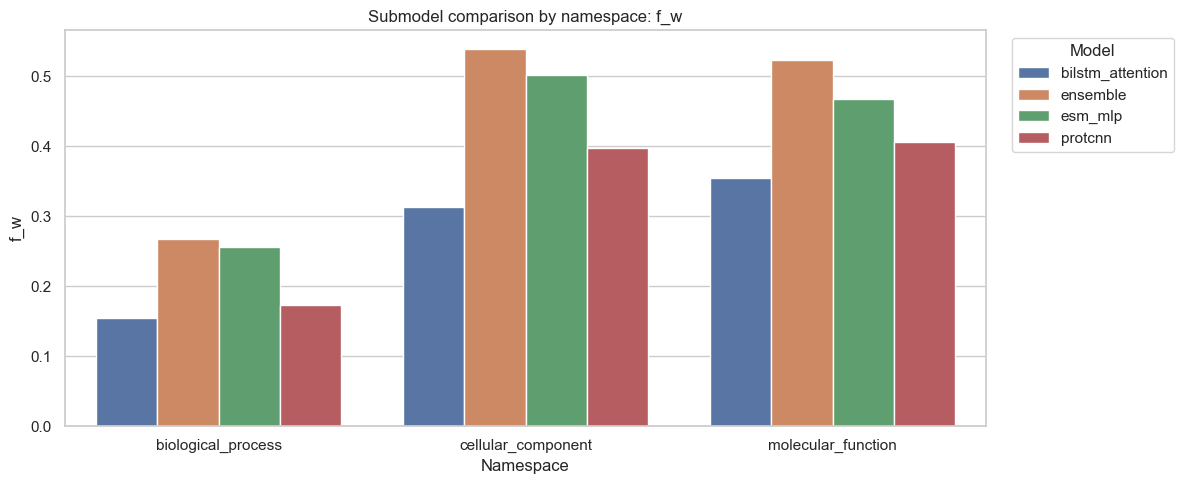

In [5]:
# =============================
# 4. Submodel comparison table on preferred metric
# =============================
preferred = fw_col or f_col or f_micro_w_col or f_micro_col
if preferred is None:
    raise ValueError("No preferred F metric found")

sub = best_by_metric(eval_all[eval_all["_result_set"] == "submodels"], preferred, True)
cols = []
for c in ["_method", "_namespace", "_threshold", preferred, f_col, fw_col, f_micro_col, f_micro_w_col, s_col]:
    if c and c in sub.columns and c not in cols:
        cols.append(c)
sub_compact = sub[cols].sort_values(["_namespace", preferred], ascending=[True, False])
print(f"Preferred metric: {preferred}")
display(sub_compact)

plt.figure(figsize=(12, 5))
sns.barplot(data=sub, x="_namespace", y=preferred, hue="_method")
plt.title(f"Submodel comparison by namespace: {preferred}")
plt.xlabel("Namespace")
plt.ylabel(preferred)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

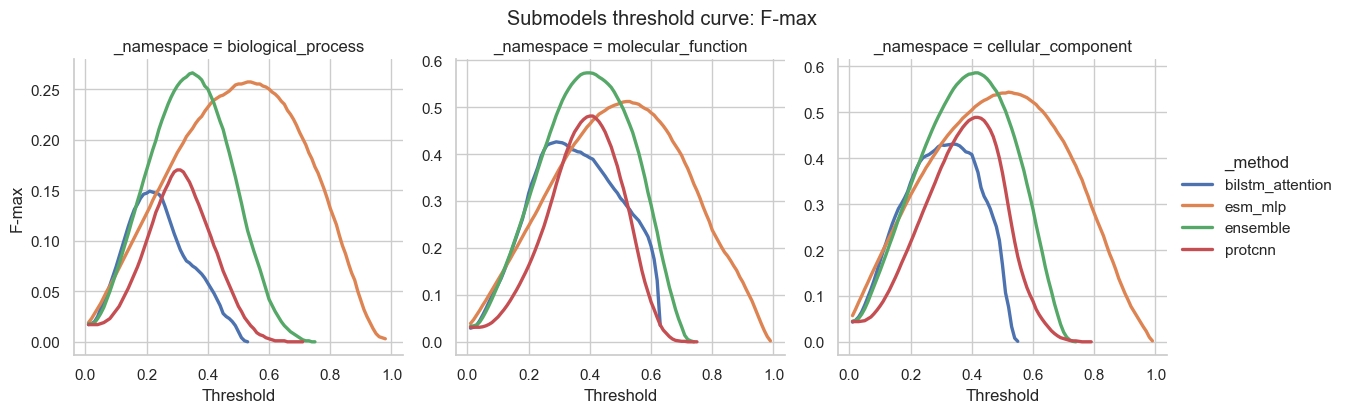

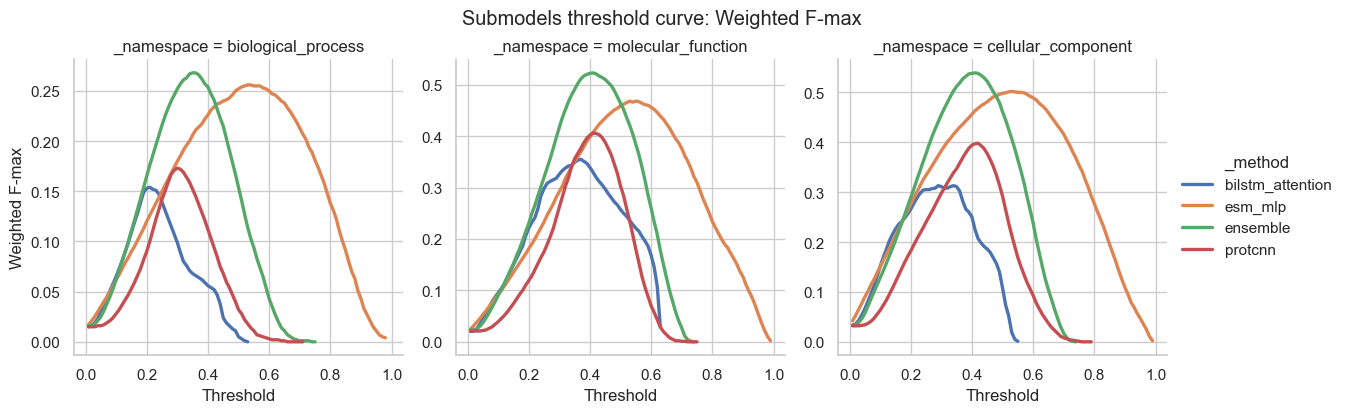

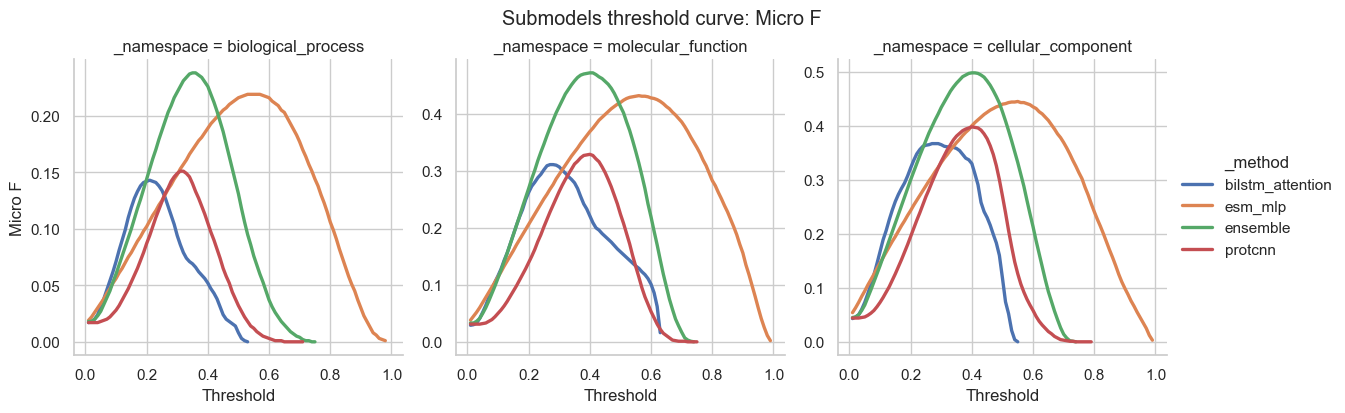

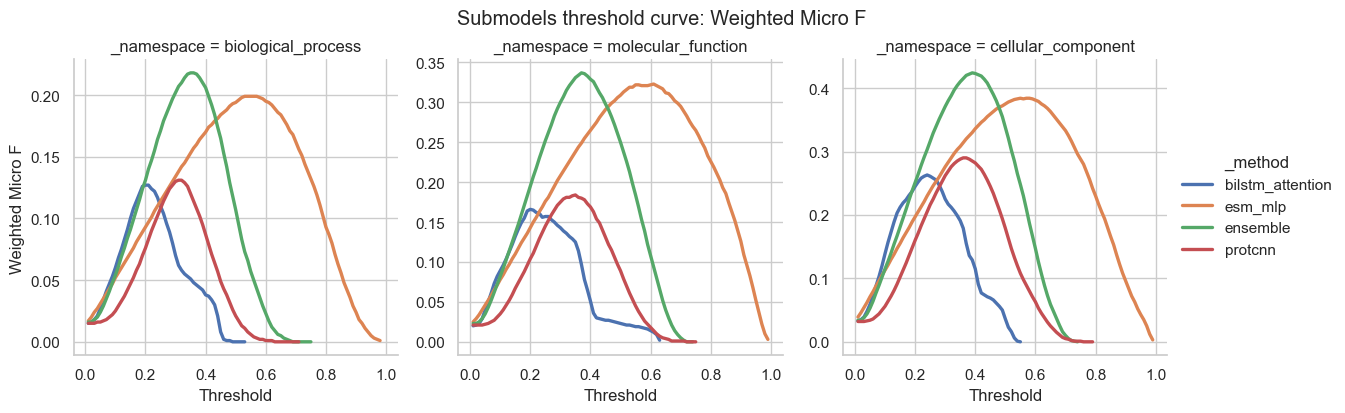

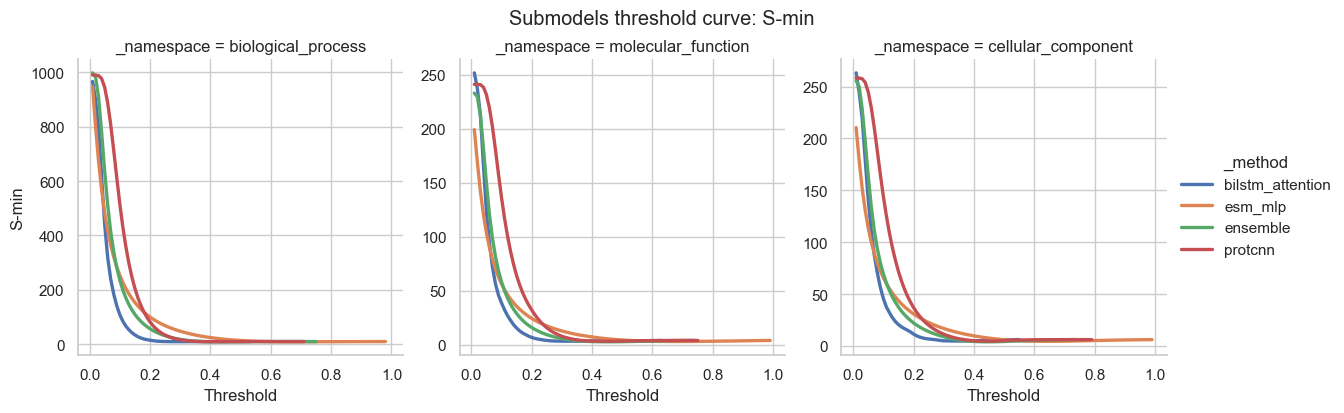

In [6]:
# =============================
# 5. Threshold curves for submodels
# =============================
metrics_to_plot = [
    ("F-max", f_col),
    ("Weighted F-max", fw_col),
    ("Micro F", f_micro_col),
    ("Weighted Micro F", f_micro_w_col),
    ("S-min", s_col),
]
metrics_to_plot = [(name, col) for name, col in metrics_to_plot if col is not None and col in eval_all.columns]
sub_eval = eval_all[eval_all["_result_set"] == "submodels"].copy()

if threshold_col is None:
    print("No threshold column found; cannot draw threshold curves.")
else:
    for name, col in metrics_to_plot:
        g = sns.relplot(
            data=sub_eval.dropna(subset=["_threshold", col]),
            x="_threshold",
            y=col,
            hue="_method",
            col="_namespace",
            kind="line",
            marker=None,
            linewidth=2.4,
            col_wrap=3,
            height=4,
            facet_kws={"sharey": False},
        )
        g.fig.suptitle(f"Submodels threshold curve: {name}", y=1.03)
        g.set_axis_labels("Threshold", name)
        plt.show()

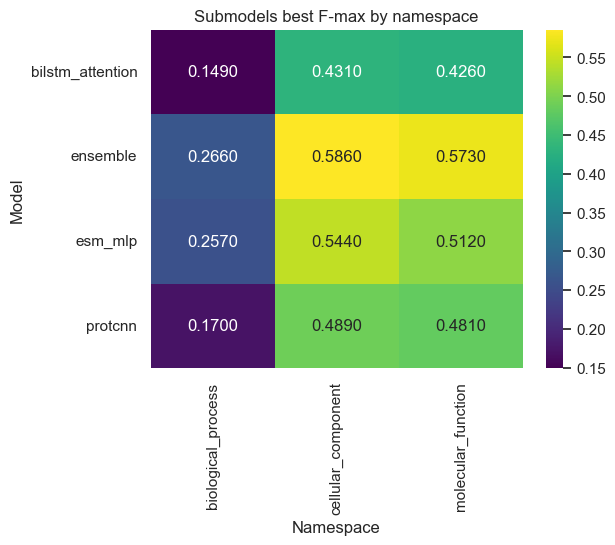

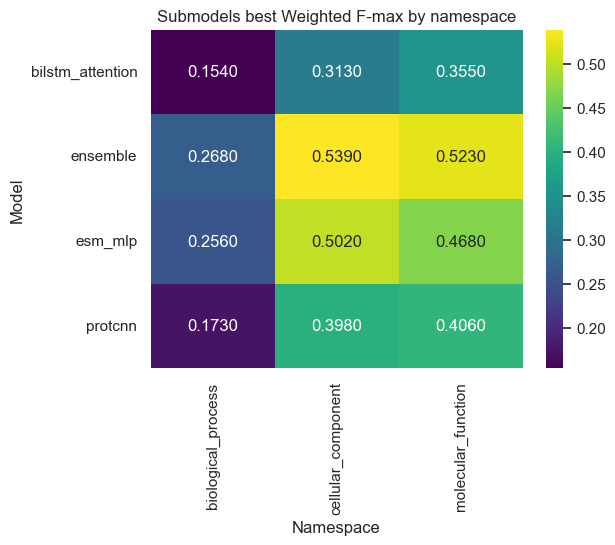

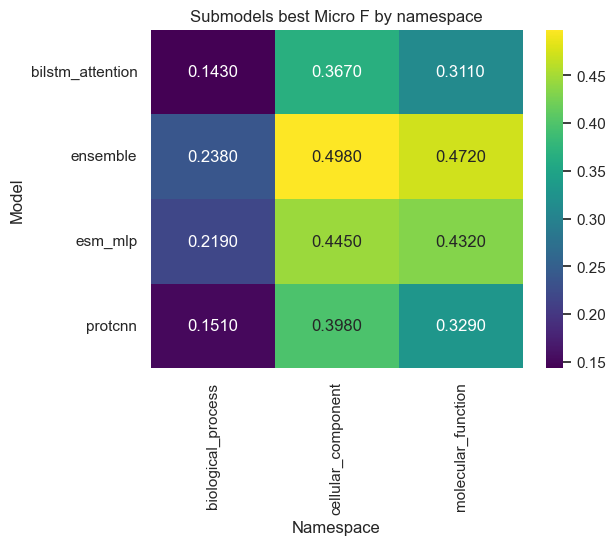

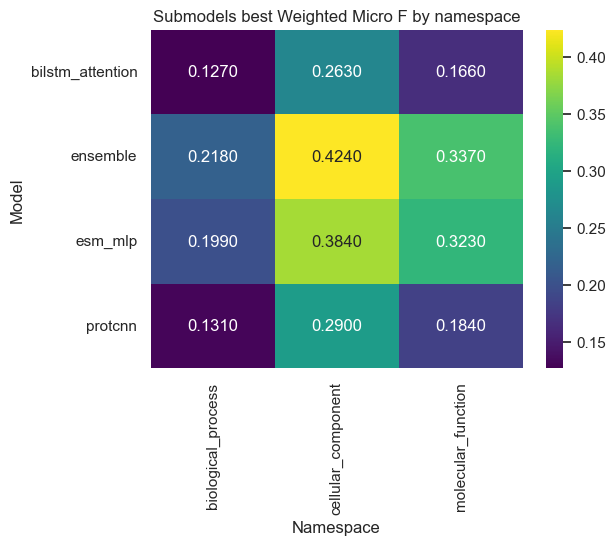

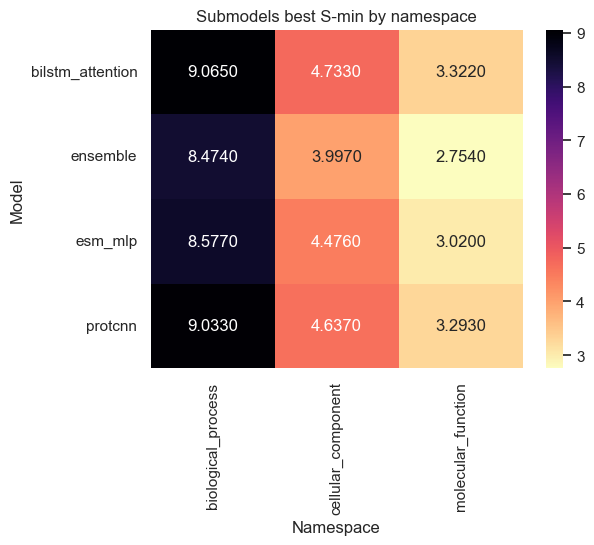

In [7]:
# =============================
# 6. Heatmaps for submodels
# =============================
for name, metric_col, higher in [
    ("F-max", f_col, True),
    ("Weighted F-max", fw_col, True),
    ("Micro F", f_micro_col, True),
    ("Weighted Micro F", f_micro_w_col, True),
    ("S-min", s_col, False),
]:
    if metric_col is None or metric_col not in sub_eval.columns:
        continue
    tmp = best_by_metric(sub_eval, metric_col, higher)
    if not len(tmp):
        continue
    pivot = tmp.pivot_table(index="_method", columns="_namespace", values=metric_col, aggfunc="max" if higher else "min")
    plt.figure(figsize=(max(6, 1.4 * pivot.shape[1]), max(3, 0.6 * pivot.shape[0] + 2)))
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis" if higher else "magma_r")
    plt.title(f"Submodels best {name} by namespace")
    plt.xlabel("Namespace")
    plt.ylabel("Model")
    plt.show()

,_result_set,_method,_namespace,_threshold,f_w,f,f_micro,f_micro_w,s
0,ensemble_original,graph_aware,biological_process,0.35,0.268,0.266,0.238,0.218,11.024
3,submodels,ensemble,biological_process,0.35,0.268,0.266,0.238,0.218,11.024
1,ensemble_original,graph_aware,cellular_component,0.41,0.539,0.586,0.498,0.421,4.214
4,submodels,ensemble,cellular_component,0.41,0.539,0.586,0.498,0.421,4.214
2,ensemble_original,graph_aware,molecular_function,0.41,0.523,0.572,0.472,0.326,2.880
5,submodels,ensemble,molecular_function,0.41,0.523,0.572,0.472,0.326,2.880


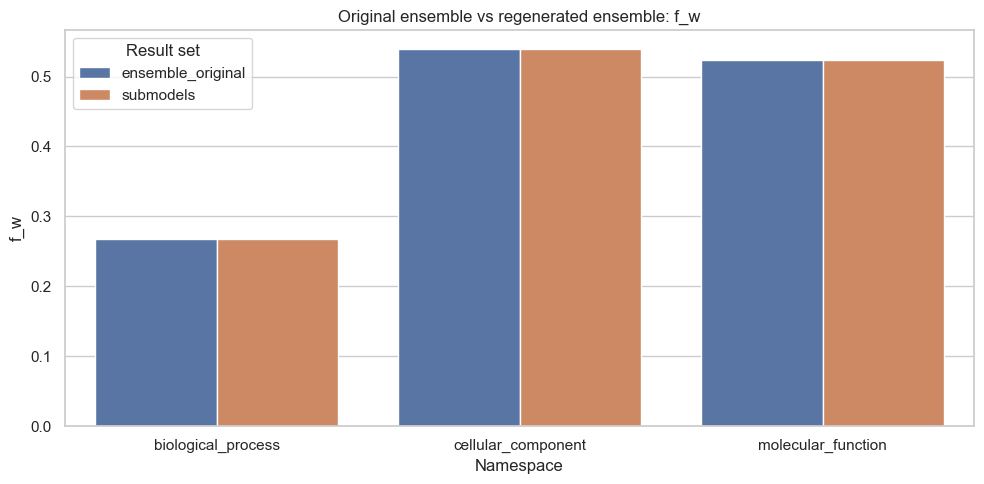

In [8]:
# =============================
# 7. Original ensemble vs regenerated ensemble
# =============================
orig = best_by_metric(eval_all[eval_all["_result_set"] == "ensemble_original"], preferred, True)
regen = best_by_metric(eval_all[(eval_all["_result_set"] == "submodels") & (eval_all["_method"] == "ensemble")], preferred, True)
compare = pd.concat([orig, regen], ignore_index=True)
cols = []
for c in ["_result_set", "_method", "_namespace", "_threshold", preferred, f_col, fw_col, f_micro_col, f_micro_w_col, s_col]:
    if c and c in compare.columns and c not in cols:
        cols.append(c)
display(compare[cols].sort_values(["_namespace", "_result_set"]))

if len(compare):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=compare, x="_namespace", y=preferred, hue="_result_set")
    plt.title(f"Original ensemble vs regenerated ensemble: {preferred}")
    plt.xlabel("Namespace")
    plt.ylabel(preferred)
    plt.legend(title="Result set")
    plt.tight_layout()
    plt.show()

In [9]:
# =============================
# 8. Final compact ranking
# =============================
rank = best_by_metric(sub_eval, preferred, True)
rank_cols = []
for c in ["_method", "_namespace", "_threshold", preferred, s_col]:
    if c and c in rank.columns and c not in rank_cols:
        rank_cols.append(c)
rank = rank[rank_cols]
rank = rank.sort_values(["_namespace", preferred], ascending=[True, False])
print(f"Ranking by {preferred} (higher is better):")
display(rank)

Ranking by f_w (higher is better):


,_method,_namespace,_threshold,f_w,s
3,ensemble,biological_process,0.35,0.268,11.024
6,esm_mlp,biological_process,0.53,0.256,11.607
9,protcnn,biological_process,0.30,0.173,16.067
0,bilstm_attention,biological_process,0.21,0.154,12.699
4,ensemble,cellular_component,0.41,0.539,4.214
7,esm_mlp,cellular_component,0.53,0.502,5.377
10,protcnn,cellular_component,0.42,0.398,4.757
1,bilstm_attention,cellular_component,0.29,0.313,5.299
5,ensemble,molecular_function,0.41,0.523,2.880
8,esm_mlp,molecular_function,0.53,0.468,3.935


,_method,overall_mean_f_w
1,ensemble,0.443333
2,esm_mlp,0.408667
3,protcnn,0.325667
0,bilstm_attention,0.274000


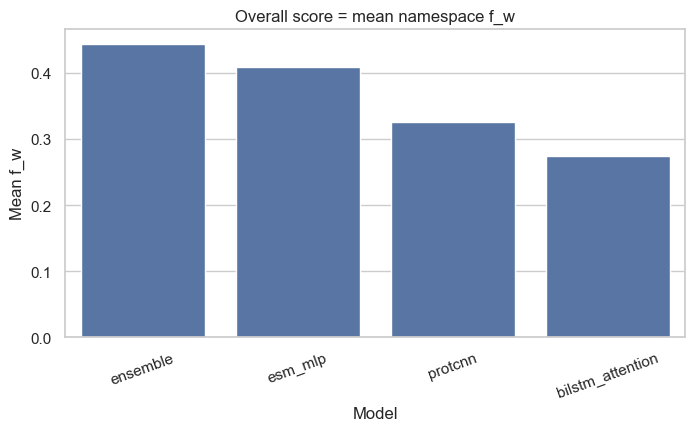

In [10]:
# Overall score by averaging namespaces
preferred = fw_col or f_col

overall = (
    best_by_metric(sub_eval, preferred, True)
    .groupby("_method")[preferred]
    .mean()
    .reset_index()
    .sort_values(preferred, ascending=False)
)

overall = overall.rename(columns={preferred: f"overall_mean_{preferred}"})
display(overall)

plt.figure(figsize=(8, 4))
sns.barplot(data=overall, x="_method", y=f"overall_mean_{preferred}")
plt.title(f"Overall score = mean namespace {preferred}")
plt.xlabel("Model")
plt.ylabel(f"Mean {preferred}")
plt.xticks(rotation=20)
plt.show()